# Natural Language Processing

#### Part 1

In [1]:
import pandas as pd

In [2]:
import numpy as np


In [3]:
import nltk

In [8]:
nltk.download_shell()

NLTK Downloader
---------------------------------------------------------------------------
    d) Download   l) List    u) Update   c) Config   h) Help   q) Quit
---------------------------------------------------------------------------

Download which package (l=list; x=cancel)?


        Sarante\AppData\Roaming\nltk_data...
      Package stopwords is already up-to-date!



---------------------------------------------------------------------------
    d) Download   l) List    u) Update   c) Config   h) Help   q) Quit
---------------------------------------------------------------------------

---------------------------------------------------------------------------
    d) Download   l) List    u) Update   c) Config   h) Help   q) Quit
---------------------------------------------------------------------------


In [9]:
messages = [line.rstrip() for line in open(r'C:\Users\Erick J. Sarante\Desktop\Erick_Curso\Data_Sci_2\#20 Natural Language Processing\smsspamcollection\SMSSpamCollection')]


In [10]:
print(len(messages))

5574


In [11]:
messages[50]

'ham\tWhat you thinked about me. First time you saw me in class.'

In [12]:
for mess_no, message in enumerate(messages[:10]):
    print(mess_no,message)
    print('\t')

0 ham	Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
	
1 ham	Ok lar... Joking wif u oni...
	
2 spam	Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
	
3 ham	U dun say so early hor... U c already then say...
	
4 ham	Nah I don't think he goes to usf, he lives around here though
	
5 spam	FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, Â£1.50 to rcv
	
6 ham	Even my brother is not like to speak with me. They treat me like aids patent.
	
7 ham	As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune
	
8 spam	WINNER!! As a valued network customer you have been selected to receivea Â£900 prize reward! To claim call 09061701461. Claim cod

In [13]:
messages = pd.read_csv(r'C:\Users\Erick J. Sarante\Desktop\Erick_Curso\Data_Sci_2\#20 Natural Language Processing\smsspamcollection\SMSSpamCollection',
                       sep='\t', names=['Label', 'message'])
messages.head()

,Label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [14]:
messages.describe()

,Label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


para saber que tanto mensajes vemos y cuantos spam tenemos

In [15]:
messages.groupby('Label').describe()

message                                                               
        count unique                                                top freq
Label                                                                       
ham      4825   4516                             Sorry, I'll call later   30
spam      747    653  Please call our customer service representativ...    4

Ahora pasamos al features engineering , que no es mas que hacer, (ver cuaderno)

In [16]:
messages['length'] = messages['message'].apply(len)

In [17]:
messages.head()

,Label,message,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

<Axes: ylabel='Frequency'>

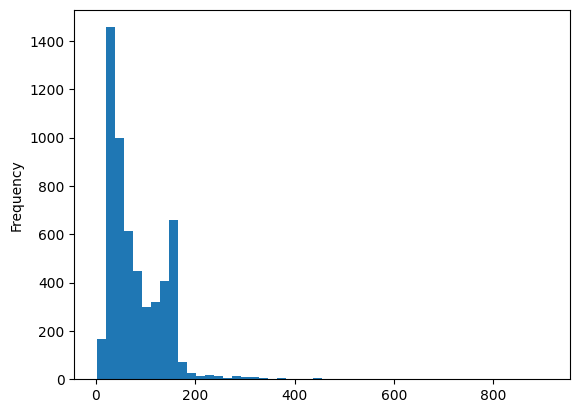

In [19]:
messages['length'].plot.hist(bins=50)

In [20]:
messages['length'].describe()

count    5572.000000
mean       80.489950
std        59.942907
min         2.000000
25%        36.000000
50%        62.000000
75%       122.000000
max       910.000000
Name: length, dtype: float64

In [21]:
messages[messages['length']==910]['message'].iloc[0]

"For me the love should start with attraction.i should feel that I need her every time around me.she should be the first thing which comes in my thoughts.I would start the day and end it with her.she should be there every time I dream.love will be then when my every breath has her name.my life should happen around her.my life will be named to her.I would cry for her.will give all my happiness and take all her sorrows.I will be ready to fight with anyone for her.I will be in love when I will be doing the craziest things for her.love will be when I don't have to proove anyone that my girl is the most beautiful lady on the whole planet.I will always be singing praises for her.love will be when I start up making chicken curry and end up makiing sambar.life will be the most beautiful then.will get every morning and thank god for the day because she is with me.I would like to say a lot..will tell later.."

array([<Axes: title={'center': 'ham'}>, <Axes: title={'center': 'spam'}>],
      dtype=object)

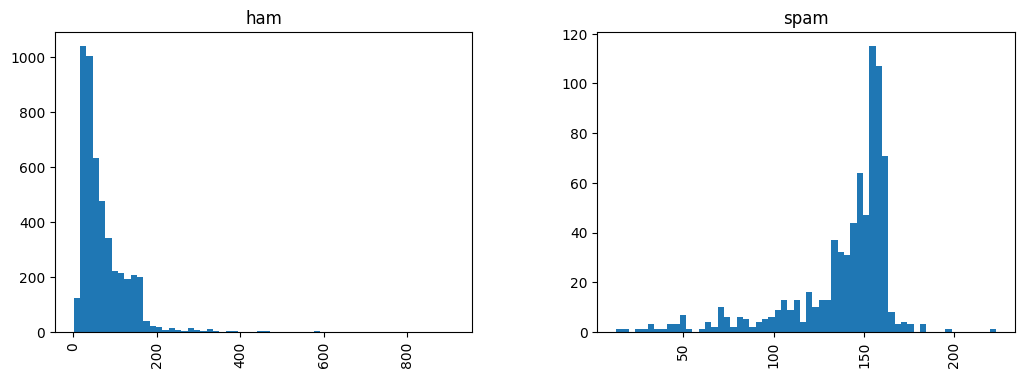

In [22]:
messages.hist(column='length', by='Label', bins=60, figsize=(12,4))

interesante ver que los mensajes de spam suelen tener mucho mas caracteres, por lo que podemos ver una tendencia aqui; por lo que la longitud de los mensajes podemos tomarla como una buena caracteristica para poder identificar los mesajes reales legitmos de los spams

#### Part 2

utilizaremos  Bag of words como representacion del texto en vectores

In [23]:
import string

In [24]:
mess = 'Sample message! Notice: it has punctuation.'

In [25]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

lo que hacemos con esto es que quitamos estos caracteres raros que no aportan nada al analisis

In [26]:
nopunc = [c for c in mess if c not in string.punctuation]
nopunc

['S',
 'a',
 'm',
 'p',
 'l',
 'e',
 ' ',
 'm',
 'e',
 's',
 's',
 'a',
 'g',
 'e',
 ' ',
 'N',
 'o',
 't',
 'i',
 'c',
 'e',
 ' ',
 'i',
 't',
 ' ',
 'h',
 'a',
 's',
 ' ',
 'p',
 'u',
 'n',
 'c',
 't',
 'u',
 'a',
 't',
 'i',
 'o',
 'n']

ahora quitaremos los stop words

In [27]:
from nltk.corpus import stopwords

In [28]:
stopwords.words('English')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [29]:
nopunc = ''.join(nopunc)
nopunc

'Sample message Notice it has punctuation'

In [30]:
nopunc.split()

['Sample', 'message', 'Notice', 'it', 'has', 'punctuation']

In [31]:
clean_mess = [word for word in nopunc.split() if word.lower() not in stopwords.words('English')]
clean_mess

['Sample', 'message', 'Notice', 'punctuation']

In [32]:
clean_mess = [] ## esta es la forma de no hacerlo en list comprenhension
for i in nopunc.split():
    if i.lower() not in stopwords.words('English'):
        clean_mess.append(i)
    else:
        pass

In [33]:
clean_mess

['Sample', 'message', 'Notice', 'punctuation']

lo que hicimos arriba fue todo el procemo de limpieza y que sabemos que es el que lleva este proceso
por lo que ahora coimo sabemos que reciclaremos este codigo lo metemos en una funcion para poder trabajar cuando nos plazca con el

In [34]:
def text_process(mess):
    """
    1. Remove punc
    2. Remove stops words
    3. Return lsit of clen text words
    """

    nopunc = [char for char in mess if char not in string.punctuation]
    
    nopunc = ''.join(nopunc)

    return [word for word in nopunc.split() if word.lower() not in stopwords.words('English')]

este proceso de limpieza seria lo que le llamamos TOKENIZACION,  ya que lo que hacemos es tomar stirng y arman token que no son mas que las palabras separadas y limpias de las que no queremos como son las stopword

In [35]:
messages.head()

,Label,message,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [36]:
messages['message'].head(5).apply(text_process)

0    [Go, jurong, point, crazy, Available, bugis, n...
1                       [Ok, lar, Joking, wif, u, oni]
2    [Free, entry, 2, wkly, comp, win, FA, Cup, fin...
3        [U, dun, say, early, hor, U, c, already, say]
4    [Nah, dont, think, goes, usf, lives, around, t...
Name: message, dtype: object

Basicamente tokenisamos como podemos ver, una cosita sencilla para normalizar 

--> tambien importante seria hacer **Stemming** y **Lemmatization**: Reducir las palabras a su raíz o forma base. Por ejemplo, "corriendo", "corrió" y "corre" se reducirían a "corr".

pero con este data set tendraimos problemas ppor su composicion por lo que lo saltariamos pero hacer eco de que seria lo siguiente hacer para un proyecto normal

**Vectorizacion**

seguimops con la tokenizacion, entonces lo volveremos token que seran vectores que es estos vectores los que la **PC** va a entender cuanod pasemos por el modelo

1. contar cuant as veces una palabra sucede en un mesaje
2. pesar estos conteos, por lo que las que aparexcan mas se le da menor peso (Inverse document frenquency)
3. Normalizar los vectores a la longitud unitaria, para abstraerlos de la longitud del texto original (norma L2)

Esto nos dara un matriz del tamaño o dimesion, tantas filas como palabras unicas y columnas como tantos mesajes xxxx / 500(que son las filas del df que eran cada uno de los mensajes por poner un ejemplo)

In [37]:
from sklearn.feature_extraction.text import CountVectorizer

con esto lo que haremos que como esta matrix de 2d pero enorme en vez que quede como matrix lo volvera vector a la palabra

In [38]:
#bag og words
bow_transformers = CountVectorizer(analyzer=text_process).fit(messages['message'])

In [39]:
print(len(bow_transformers.vocabulary_))

11425


el vocabulario de nuestro data set esta compuesto de 11425 palabras 

In [40]:
mess4 = messages['message'][3]

aca tomando solo una frase no quedamos con ella y vemos como la tokeniza para ver que hace el codigo

In [41]:
mess4

'U dun say so early hor... U c already then say...'

dandonos asi que de un solo mesajes y de las 11425 palabras solo nosquedamos con klas coordenadas de las palabras que nos importan que son las de este mensaje diceindonos que coordenada es unica y cual ser repite en el caso de la 0, 4068 que ocurre dos veces ne nuestro mesaje que vemos 

In [42]:
bow4 = bow_transformers.transform([mess4])
print(bow4)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 7 stored elements and shape (1, 11425)>
  Coords	Values
  (0, 4068)	2
  (0, 4629)	1
  (0, 5261)	1
  (0, 6204)	1
  (0, 6222)	1
  (0, 7186)	1
  (0, 9554)	2


In [43]:
print(bow4.shape)

(1, 11425)


por lo que si vemos esta corrdeanda veremos que compagina con la info que nos dio arriba de repeticion en la frase que hemos sacado

In [44]:
bow_transformers.get_feature_names_out()[4068]

'U'

#### Part 3

In [45]:
messages_bow = bow_transformers.transform(messages['message'])

In [46]:
print('Sahper of Sparse matrix: ', messages_bow.shape)

Sahper of Sparse matrix:  (5572, 11425)


tenemos aqui filas 5572 mesajes y 11425 mesaajes

In [47]:
messages_bow.nnz

50548

El atributo .nnz significa "number of non-zero" (número de no ceros). El valor de 50548 indica que hay 50,548 entradas en la matriz que no son cero. Cada entrada no cero significa que una palabra específica (representada por una columna) aparece en un mensaje específico (representado por una fila). El valor de la entrada podría ser la frecuencia con la que la palabra aparece en el documento.

In [48]:
sparsity = (100.0 * messages_bow.nnz / (messages_bow.shape[0] * messages_bow.shape[1]))
print('sparsity: {}'.format(sparsity))

sparsity: 0.07940295412668218


El valor de sparsity te dice cuán "vacía" está tu matriz. Un valor bajo (cercano a 0) indica que la matriz es muy dispersa o "escasa", lo que significa que la inmensa mayoría de sus celdas son ceros. Por el contrario, un valor alto (cercano a 100) indicaría que la matriz es "densa", con pocos o ningún cero.

En el contexto de tu conjunto de datos de texto, el resultado de sparsity te dice el porcentaje de veces que las palabras de tu vocabulario aparecen en los mensajes. Un valor de escasez bajo es lo habitual en el procesamiento de lenguaje natural, ya que cada mensaje solo contiene una pequeña fracción de todas las palabras únicas que existen en tu vocabulario completo.

 un valor de escasez bajo es la norma y una señal de que el modelo está funcionando como debería para representar datos de texto de forma eficiente. No es una métrica de rendimiento del modelo, sino una métrica de las características inherentes de tus datos.

In [49]:
from sklearn.feature_extraction.text import TfidfTransformer

In [50]:
ifidf_transformer = TfidfTransformer().fit(messages_bow)

In [51]:
tfidf4 = ifidf_transformer.transform(bow4)

In [52]:
print(tfidf4)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7 stored elements and shape (1, 11425)>
  Coords	Values
  (0, 4068)	0.4083258993338407
  (0, 4629)	0.2661980190608719
  (0, 5261)	0.2972995740586873
  (0, 6204)	0.2995379972369742
  (0, 6222)	0.31872168929491496
  (0, 7186)	0.4389365653379858
  (0, 9554)	0.5385626262927565


¿Qué significa esta matriz?
Este es el resultado final del cálculo de TF-IDF para un solo mensaje.

shape (1, 11425): Esto significa que es un vector que representa un solo documento (fila 1) en un vocabulario de 11,425 palabras (columnas).

7 stored elements: Indica que solo 7 palabras en ese mensaje tienen un valor TF-IDF distinto de cero.

Coords: Muestra la ubicación de esas palabras. El primer número (0) es el índice del documento (el primero y único), y el segundo número es el índice de la palabra en el vocabulario. Por ejemplo, (0, 4068) significa que la palabra en la posición 4068 del vocabulario tiene un valor TF-IDF de 0.4083....

Values: Estos son los valores TF-IDF calculados para cada una de esas 7 palabras.

Interpretación de los valores
Cada uno de esos números (0.408, 0.266, etc.) representa la importancia de una palabra en particular para ese mensaje específico, considerando su rareza en toda la colección de 11,425 mensajes.

El valor más alto es 0.538... para la palabra en el índice 9554. Esto significa que, de las 7 palabras en ese mensaje, esa es la más importante y distintiva según el modelo TF-IDF.

El valor más bajo es 0.266... para la palabra en el índice 4629. Esta es la menos importante de las 7, aunque sigue siendo relevante.

In [53]:
ifidf_transformer.idf_[bow_transformers.vocabulary_['university']]

np.float64(8.527076498901426)

este es un nuemro alto y nos dice que la palabra es rara (ver formula de IDF)

ya en este siguiente paso en ves de utilizar un solo mesaje utilizaremos todos para poder sacar de aqui la importancia de las palabras

In [54]:
messages_tfdidf = ifidf_transformer.transform(messages_bow)

teniendo esto entonces podemos proceder a hacer el clasificador de mensajes si son spam o no

la forma mas naive en este caso funcionaria perfectamente

In [55]:
from sklearn.naive_bayes import MultinomialNB

In [56]:
spam_detect_model = MultinomialNB().fit(messages_tfdidf,messages['Label'])

In [65]:
spam_detect_model.predict(tfidf4)[0]

np.str_('ham')

aqui ya entrenado pues le decimos que nos prediga un mensaje de los que estaba en el vocabulario que seri el del indice 4 (0,1,2,3 osea 3)

In [ ]:
messages.iloc[3:4] # que efectivamente es un ham osea un buen mensaje

,Label,message,length
3,ham,U dun say so early hor... U c already then say...,49


In [66]:
all_pred = spam_detect_model.predict(messages_tfdidf)

tener en cuenta que no dividimos el data set para entrenar y testear por lo que este ahora mismo esta predijendo lo aprendido y lo hara al dedillo. por lo que es lo que haremos ahora

In [69]:
all_pred

array(['ham', 'ham', 'spam', ..., 'ham', 'ham', 'ham'],
      shape=(5572,), dtype='<U4')

In [70]:
from sklearn.model_selection import train_test_split

In [77]:
msg_train, msg_test, label_train, label_test = train_test_split(messages['message'], messages['Label'],
                                                             test_size=0.33, random_state=42)

In [78]:
msg_train

3235                                  Yup ü not comin :-(
945     I sent my scores to sophas and i had to do sec...
5319                         Kothi print out marandratha.
5528    Its just the effect of irritation. Just ignore it
247                        I asked you to call him now ok
                              ...                        
3772    Hi, wlcome back, did wonder if you got eaten b...
5191                               Sorry, I'll call later
5226        Prabha..i'm soryda..realy..frm heart i'm sory
5390                           Nt joking seriously i told
860               Did he just say somebody is named tampa
Name: message, Length: 3733, dtype: object

teniendo devido asi puedo tomar la train data de msg_train y hacer todo el proceso de arriba de crear todo, esto es una opcion y es valida, pero SKLEARN tiene un pip line que hace todo el proceso y es lo que haremos nosotros por que sino tendriamos que ir haceindo cada paso desde armar el BOW y ajustar y clasificar

In [75]:
from sklearn.pipeline import Pipeline

In [79]:
pipeline = Pipeline([
    ('bow', CountVectorizer(analyzer=text_process)),
    ('tfidf', TfidfTransformer()),
    ('classifier', MultinomialNB())
])

In [80]:
pipeline.fit(msg_train,label_train)

,steps,"[('bow', ...), ('tfidf', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [81]:
predicciones = pipeline.predict(msg_test)

In [82]:
from sklearn.metrics import classification_report

In [83]:
print(classification_report(label_test,predicciones))

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98      1593
        spam       1.00      0.74      0.85       246

    accuracy                           0.96      1839
   macro avg       0.98      0.87      0.91      1839
weighted avg       0.97      0.96      0.96      1839

